<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/fertilizer-scheduling-model/FerilizerSchedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [183]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import matplotlib.gridspec as gridspec

Cleaning Data, Preprocessing data and feature engineering for Fertilizer dataset.

In [185]:
#fertilizer dataset
fert = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Fertilizer_History.csv', header=None)
fert.columns = ["Division", "Field", "Area", "Type", "Date", "Amount", "Block", "Extra"]
fert = fert.drop(columns=["Extra"]).dropna(how='all')

fert['Division'] = fert['Division'].ffill()
fert = fert[fert['Field'].notna() & (fert['Field'] != 0) & (fert['Field'] != '-') & (fert['Field'] != 'Field')]
fert = fert[fert['Division'] != 'Division']

fert['Area']   = pd.to_numeric(fert['Area'],   errors='coerce')
fert['Amount'] = pd.to_numeric(fert['Amount'], errors='coerce')
fert = fert.dropna(subset=['Area','Amount'])
fert['Date'] = fert['Date'].astype(str).str.replace('Sept', 'Sep', regex=False)
fert['Date'] = pd.to_datetime(fert['Date'], format='%d-%b-%y', errors='coerce')
fert = fert.dropna(subset=['Date'])
fert = fert[fert['Date'].dt.year > 2000]

fert['Month'] = fert['Date'].dt.strftime('%B')

#Feature Engineer
fert['Fertilizer_per_area'] = fert['Amount'] / fert['Area']
fert = fert.sort_values(by=['Division','Field','Date']).reset_index(drop=True)

print("Fert shape:", fert.shape)
print(fert[['Division','Field','Date','Amount']].head())

Fert shape: (65, 9)
  Division Field       Date  Amount
0      AGO    3A 2023-02-12    30.0
1      AGO    3B 2023-08-18    24.0
2      AGO    4A 2024-08-31    11.0
3      AGO    9G 2025-02-02     6.0
4      AGO    9H 2024-03-21    16.0


Cleaning Data, Preprocessing data and feature engineering for the yeild dataset.

In [186]:
#yeild dataset
yield_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Block_Metadata.csv', header=None)
yield_df = yield_df.dropna(how='all').reset_index(drop=True)
yield_df = yield_df.iloc[4:].reset_index(drop=True)

yield_df.columns = [
    'Division', 'Asst_Manager', 'Field', 'Area', 'Type',
    'Planting_Year', 'Last_Pruned', 'Age_Months'
] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]

#Clean numeric columns
numeric_cols = ['Area','Age_Months'] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]
for col in numeric_cols:
    yield_df[col] = pd.to_numeric(yield_df[col].astype(str).str.replace(',',''), errors='coerce')
yield_df[numeric_cols] = yield_df[numeric_cols].fillna(yield_df[numeric_cols].median())
yield_df['Division'] = yield_df['Division'].ffill()
yield_df['Field'] = yield_df['Field'].ffill()
yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)

#Feature engineering
yield_df['Yield_per_ha'] = yield_df['Year_1'] / yield_df['Area']
last_5_cols = [col for col in yield_df.columns if 'Year_' in col][:5]
yield_df['Avg_Yield_Last5Y'] = yield_df[last_5_cols].mean(axis=1)
yield_df['Yield_Trend'] = yield_df['Year_1'] - yield_df['Avg_Yield_Last5Y']
yield_df['Months_Since_Pruning'] = yield_df['Age_Months'] - ((pd.to_datetime('2025-09-01') - yield_df['Last_Pruned']).dt.days/30)
yield_df['Months_Since_Pruning'] = yield_df['Months_Since_Pruning'].fillna(yield_df['Months_Since_Pruning'].median())

yield_features = yield_df[['Division','Field','Area','Age_Months','Yield_per_ha','Avg_Yield_Last5Y','Yield_Trend','Months_Since_Pruning']]

/tmp/ipykernel_986/4258885854.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)


Cleaning Data, Preprocessing data and feature engineering for climate dataset.

In [187]:
#Climate dataset
climate = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Climate_Data.csv', header=None)
climate = climate.dropna(how='all').reset_index(drop=True)

months = ['January','February','March','April','May','June','July','August','September','October','November','December']
climate = climate[climate[0].str.strip().isin(months)].reset_index(drop=True)

n_cols = climate.shape[1]
columns = ['Month']
num_years = (n_cols - 1)//2
for i in range(num_years):
    columns += [f'Wetdays_Year_{i+1}', f'Rainfall_Year_{i+1}']
if len(columns) != n_cols:
    columns += [f'Extra_{i}' for i in range(len(columns), n_cols)]
climate.columns = columns

# Clean numeric
for col in climate.columns[1:]:
    climate[col] = pd.to_numeric(climate[col].astype(str).str.replace(',','').str.replace('-','').str.strip(), errors='coerce')
non_empty_cols = [c for c in climate.columns if climate[c].notna().sum() > 0 or c=='Month']
climate = climate[non_empty_cols]

rainfall_cols = [c for c in climate.columns if 'Rainfall' in c]
wetdays_cols = [c for c in climate.columns if 'Wetdays' in c]

climate['Rainfall_Mean'] = climate[rainfall_cols].mean(axis=1)
climate['Rainfall_Max'] = climate[rainfall_cols].max(axis=1)
climate['Rainfall_Min'] = climate[rainfall_cols].min(axis=1)
climate['Wetdays_Mean'] = climate[wetdays_cols].mean(axis=1)

def compute_trend(row):
    y = row[rainfall_cols].values.astype(float)
    valid_idx = ~np.isnan(y)
    if valid_idx.sum()<2:
        return 0
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x[valid_idx], y[valid_idx])
    return slope

climate['Rainfall_Trend'] = climate.apply(compute_trend, axis=1)

Clean, pre-process and fature engineer plucking round dataset

In [188]:
# Plucking rounds dataset
today = pd.Timestamp.today().normalize()

df_pluck = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Last_10_Year_Data_-_PLUCKING_ROUNDS_-AS_AT_JUNE-25.csv', header=None)
df_pluck.columns = ['Field','Type','Extent','Rounds_2526','Rounds_2425','Rounds_2324']

division_map = {
    'AGROYA DIVISION': 'AGO', 'LOWER DANDUKELLEWA DIVISION': 'LDK',
    'LOWER VELLAI OYA DIVISION': 'LVO', 'UPPER DANDUKELLEWA DIVISION': 'UDK',
    'UPPER VELLAI OYA DIVISION': 'UVO'
}
df_pluck['Division'] = df_pluck['Field'].map(division_map).ffill()

pluck = df_pluck[~df_pluck['Field'].astype(str).str.contains('Division|Estate|PLUCKING|Field|Type', na=True)].copy()
pluck = pluck[pluck['Field'].notna()].copy()

#Convert to numeric
for c in ['Rounds_2526','Rounds_2425','Rounds_2324','Extent']:
    pluck[c] = pd.to_numeric(pluck[c].astype(str).str.strip().replace('-',''), errors='coerce')
pluck['Field'] = pluck['Field'].astype(str).str.strip()

#Feature engineering
pluck['Rounds_Trend'] = pluck['Rounds_2425'] - pluck['Rounds_2324']
pluck['Rounds_Pct_Change'] = ((pluck['Rounds_2425'] - pluck['Rounds_2324']) / pluck['Rounds_2324'] * 100).round(1)
pluck['Rounds_Mean'] = pluck[['Rounds_2324','Rounds_2425']].mean(axis=1)

print("Plucking rounds shape:", pluck.shape)
print(pluck[['Division','Field','Rounds_2324','Rounds_2425','Rounds_Trend','Rounds_Pct_Change']].head(10))

Plucking rounds shape: (70, 10)
   Division                        Field  Rounds_2324  Rounds_2425  \
4       AGO              AGROYA DIVISION          NaN          NaN   
5       AGO                           3A         29.0         29.0   
6       AGO                           3B         22.0         31.0   
7       AGO                           4A         30.0         21.0   
8       AGO                           9G         30.0         24.0   
9       AGO                           9H         27.0         30.0   
10      AGO                           9I         34.0         28.0   
12      LDK  LOWER DANDUKELLEWA DIVISION          NaN          NaN   
13      LDK                           44         19.0         29.0   
14      LDK                           45         32.0         30.0   

    Rounds_Trend  Rounds_Pct_Change  
4            NaN                NaN  
5            0.0                0.0  
6            9.0               40.9  
7           -9.0              -30.0  
8      

Merging the datasets


In [189]:
merged_df = pd.merge(fert, yield_features, on=['Division', 'Field'], how='left')
merged_df = pd.merge(merged_df, climate[['Month', 'Rainfall_Mean', 'Wetdays_Mean']], on='Month', how='left')
merged_df = pd.merge(
    merged_df,
    pluck[['Division', 'Field', 'Rounds_2324', 'Rounds_2425', 'Rounds_Trend', 'Rounds_Mean']],
    on=['Division', 'Field'], how='left'
)

#Using median to impute missing numeric values
num_cols = merged_df.select_dtypes(include=np.number).columns
merged_df[num_cols] = merged_df[num_cols].fillna(merged_df[num_cols].median())

merged_df['Days_Since_Application'] = (today - merged_df['Date']).dt.days

print("Merged dataset shape:", merged_df.shape)
print("Columns:", merged_df.columns.tolist())

Merged dataset shape: (65, 22)
Columns: ['Division', 'Field', 'Area_x', 'Type', 'Date', 'Amount', 'Block', 'Month', 'Fertilizer_per_area', 'Area_y', 'Age_Months', 'Yield_per_ha', 'Avg_Yield_Last5Y', 'Yield_Trend', 'Months_Since_Pruning', 'Rainfall_Mean', 'Wetdays_Mean', 'Rounds_2324', 'Rounds_2425', 'Rounds_Trend', 'Rounds_Mean', 'Days_Since_Application']


Performing Exploratory data analysis on the merged dataset

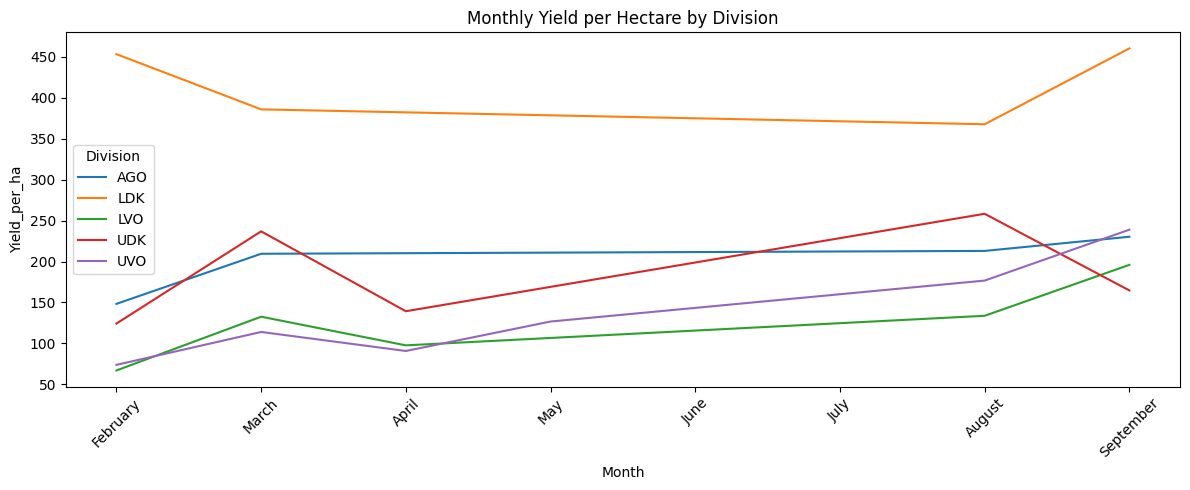

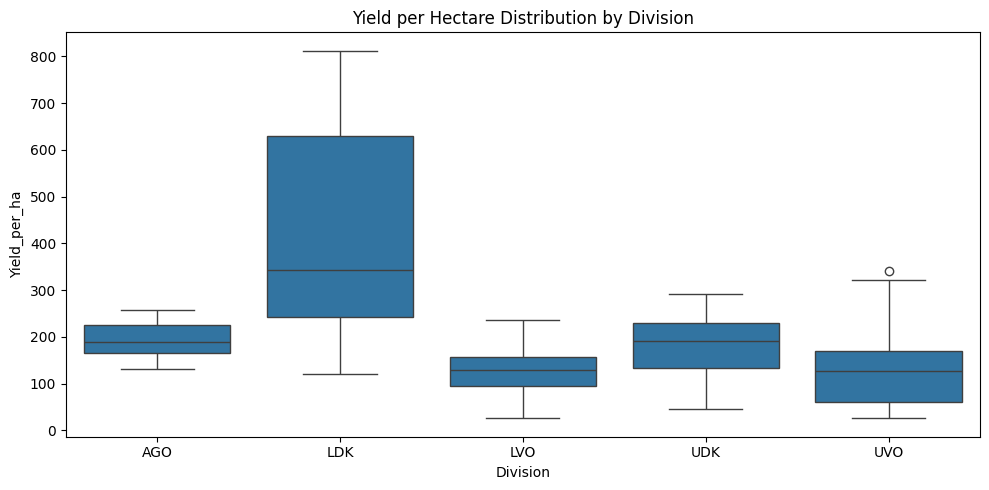

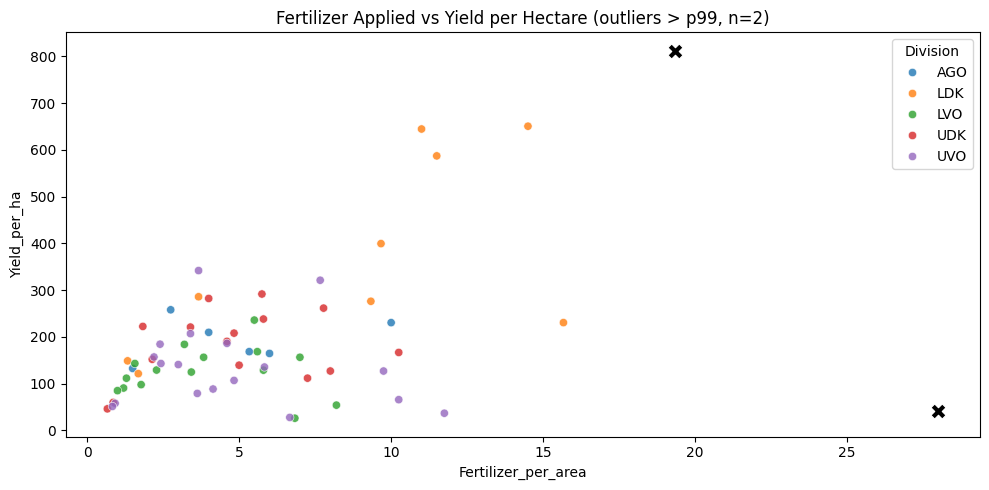

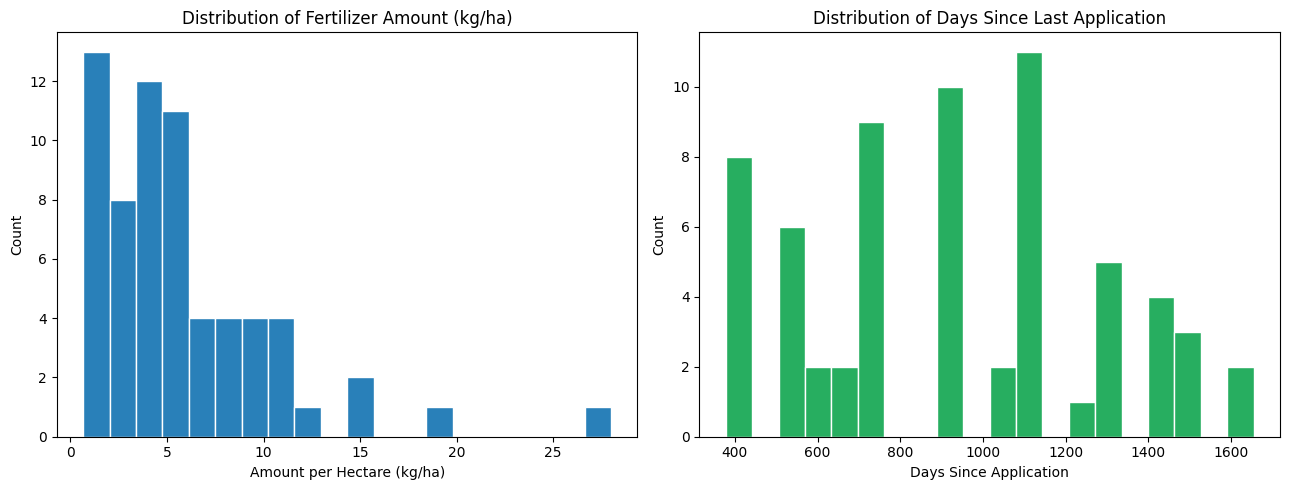

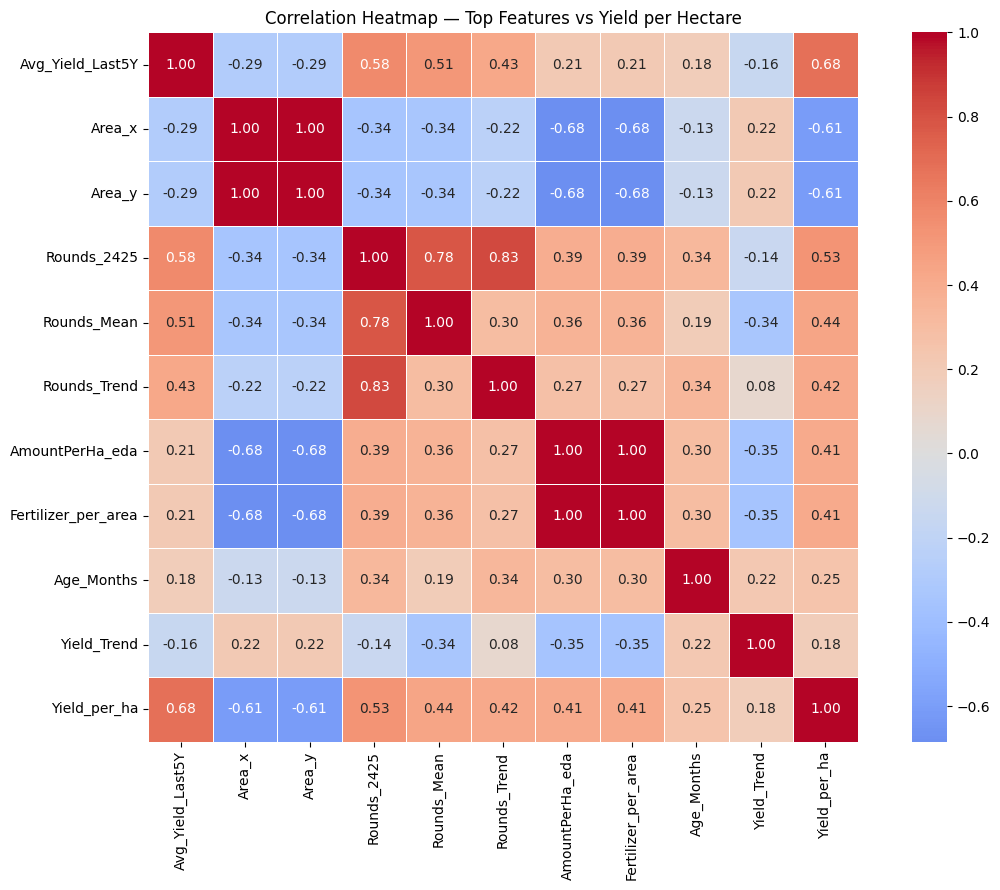

In [190]:
eda_df = merged_df.copy()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
eda_df['Month'] = pd.Categorical(eda_df['Month'], categories=month_order, ordered=True)

#Monthly Yield per Division
plt.figure(figsize=(12, 5))
sns.lineplot(data=eda_df, x='Month', y='Yield_per_ha', hue='Division', errorbar=None)
plt.title("Monthly Yield per Hectare by Division")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Yield Distribution by Division
plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_df, x='Division', y='Yield_per_ha')
plt.title("Yield per Hectare Distribution by Division")
plt.tight_layout()
plt.show()

#Fertilizer vs Yield
p99_fert = eda_df['Fertilizer_per_area'].quantile(0.99)
p99_yield = eda_df['Yield_per_ha'].quantile(0.99)
df_main = eda_df[(eda_df['Fertilizer_per_area'] <= p99_fert) & (eda_df['Yield_per_ha'] <= p99_yield)]
df_outlier = eda_df[(eda_df['Fertilizer_per_area'] > p99_fert)  | (eda_df['Yield_per_ha'] > p99_yield)]

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_main, x='Fertilizer_per_area', y='Yield_per_ha', hue='Division', alpha=0.8)
sns.scatterplot(data=df_outlier, x='Fertilizer_per_area', y='Yield_per_ha',
                marker='X', s=120, color='black', label='Outlier', legend=False)
plt.title(f"Fertilizer Applied vs Yield per Hectare (outliers > p99, n={len(df_outlier)})")
plt.tight_layout()
plt.show()

#Target variable distributions
eda_df['AmountPerHa_eda'] = eda_df['Amount'] / eda_df['Area_x']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(eda_df['AmountPerHa_eda'].dropna(), bins=20, color='#2980b9', edgecolor='white')
axes[0].set_title("Distribution of Fertilizer Amount (kg/ha)")
axes[0].set_xlabel("Amount per Hectare (kg/ha)")
axes[0].set_ylabel("Count")

axes[1].hist(eda_df['Days_Since_Application'].dropna(), bins=20, color='#27ae60', edgecolor='white')
axes[1].set_title("Distribution of Days Since Last Application")
axes[1].set_xlabel("Days Since Application")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

#Correletion heatmap
numeric_eda = eda_df.select_dtypes(include=np.number).columns
corr_matrix = eda_df[numeric_eda].corr()
top_corr = corr_matrix['Yield_per_ha'].abs().sort_values(ascending=False)[1:11]
top_features = top_corr.index.tolist() + ['Yield_per_ha']

plt.figure(figsize=(12, 9))
sns.heatmap(eda_df[top_features].corr(), annot=True, fmt=".2f",cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Top Features vs Yield per Hectare")
plt.tight_layout()
plt.show()

In [191]:
#Feature Engineering for models
merged_df['AmountPerHa'] = merged_df['Amount'] / merged_df['Area_x']
merged_df['Division_enc'] = LabelEncoder().fit_transform(merged_df['Division'])
merged_df['Yield_x_Round'] = merged_df['Yield_per_ha'] * merged_df['Rounds_Mean']
merged_df['Age_sq'] = merged_df['Age_Months'] ** 2
merged_df['Rounds_3Y_Mean'] = merged_df[['Rounds_2324', 'Rounds_2425']].mean(axis=1)

feature_cols = [
    'Avg_Yield_Last5Y', 'Yield_Trend', 'Yield_per_ha', 'Months_Since_Pruning',
    'Rainfall_Mean', 'Wetdays_Mean', 'Division_enc',
    'Age_Months', 'Age_sq', 'Rounds_2324', 'Rounds_2425', 'Rounds_Trend',
    'Rounds_Mean', 'Rounds_3Y_Mean', 'Yield_x_Round'
]

feature_cols_days = [
    'Rounds_2324', 'Rounds_Trend', 'Rounds_Mean', 'AmountPerHa', 'Division_enc',
    'Age_Months', 'Avg_Yield_Last5Y', 'Rainfall_Mean', 'Wetdays_Mean'
]

In [192]:
#Predicting fertilizer amount (kg/ha)
X_amt = merged_df[feature_cols]
y_amt = merged_df['AmountPerHa']

X_s, y_s = shuffle(X_amt, y_amt, random_state=42)
X_s = X_s.reset_index(drop=True)
y_s = y_s.reset_index(drop=True)

split_amt = int(len(X_s) * 0.8)
X_tr_raw_a = X_s.iloc[:split_amt]
X_te_raw_a = X_s.iloc[split_amt:]

train_median = X_tr_raw_a.median()
X_train = X_tr_raw_a.fillna(train_median)
X_test = X_te_raw_a.fillna(train_median)
y_train = y_s.iloc[:split_amt]
y_test = y_s.iloc[split_amt:]

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

train_r2_amt = r2_score(y_train, model.predict(X_train))
test_r2_amt = r2_score(y_test, y_pred)

print("Model 1 Performance — Fertilizer Amount (kg/ha)")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} kg/ha")
print(f"Train R2: {train_r2_amt:.3f}")
print(f"Test R2: {test_r2_amt:.3f}")
print(f"Overfit gap: {train_r2_amt - test_r2_amt:.3f}")

#Feature importance
fi_amt = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop 10 Important Features:")
print(fi_amt.head(10).round(3))

X_test_amt_eval = X_test.copy()
y_test_amt_eval = y_test.copy()
y_pred_amt_eval = y_pred.copy()

model.fit(X_amt.fillna(train_median), y_amt)
print("Model Training done")

Model 1 Performance — Fertilizer Amount (kg/ha)
MAE: 1.91 kg/ha
Train R2: 0.693
Test R2: 0.674
Overfit gap: 0.019

Top 10 Important Features:
Age_sq                  0.110
Rounds_2425             0.103
Rounds_Mean             0.097
Age_Months              0.097
Yield_x_Round           0.097
Yield_Trend             0.091
Rounds_3Y_Mean          0.077
Avg_Yield_Last5Y        0.076
Yield_per_ha            0.072
Months_Since_Pruning    0.054
dtype: float64
Model Training done


In [193]:
# Model 2: Predict Days Since Last Fertilizer Application
X_days = merged_df[feature_cols_days]
y_days = merged_df['Days_Since_Application']

X_ds, y_ds = shuffle(X_days, y_days, random_state=42)
X_ds = X_ds.reset_index(drop=True)
y_ds = y_ds.reset_index(drop=True)

split_days = int(len(X_ds) * 0.8)
X_tr_raw_d = X_ds.iloc[:split_days]
X_te_raw_d = X_ds.iloc[split_days:]

train_median_days = X_tr_raw_d.median()
X_train_d = X_tr_raw_d.fillna(train_median_days)
X_test_d  = X_te_raw_d.fillna(train_median_days)
y_train_d = y_ds.iloc[:split_days]
y_test_d = y_ds.iloc[split_days:]

model_days = RandomForestRegressor(
    n_estimators=300, max_depth=5,
    min_samples_leaf=4,
    random_state=42
)
model_days.fit(X_train_d, y_train_d)
y_pred_d = model_days.predict(X_test_d)

train_r2_days = r2_score(y_train_d, model_days.predict(X_train_d))
test_r2_days  = r2_score(y_test_d, y_pred_d)

print("Model 2 Performance — Fertilizer Interval (Days Since Application)")
print(f"MAE: {mean_absolute_error(y_test_d, y_pred_d):.0f} days")
print(f"Train R2: {train_r2_days:.3f}")
print(f"Test R2: {test_r2_days:.3f}")
print(f"Overfit gap: {train_r2_days - test_r2_days:.3f}")

fi_days = pd.Series(model_days.feature_importances_, index=feature_cols_days).sort_values(ascending=False)
print("\nTop Features:")
print(fi_days.round(3))

X_test_dys_eval = X_test_d.copy()
y_test_dys_eval = y_test_d.copy()
y_pred_dys_eval = y_pred_d.copy()

model_days.fit(X_days.fillna(train_median_days), y_days)
print("Model Training done")

Model 2 Performance — Fertilizer Interval (Days Since Application)
MAE: 131 days
Train R2: 0.921
Test R2: 0.815
Overfit gap: 0.106

Top Features:
AmountPerHa         0.730
Age_Months          0.140
Rounds_2324         0.076
Rounds_Trend        0.026
Rainfall_Mean       0.009
Wetdays_Mean        0.009
Rounds_Mean         0.004
Avg_Yield_Last5Y    0.004
Division_enc        0.002
dtype: float64
Model Training done


Intergrating both the models to predict fertilizer amount and interval days

In [194]:
merged_df['Predicted_Amount_kg'] = (model.predict(merged_df[feature_cols].fillna(train_median)) * merged_df['Area_x']).round(1)
merged_df['Predicted_Cycle_Days'] = model_days.predict( merged_df[feature_cols_days].fillna(train_median_days)).astype(int)
merged_df['Days_Until_Next'] = merged_df['Predicted_Cycle_Days'] - merged_df['Days_Since_Application']
merged_df['Next_Application_Date'] = today + pd.to_timedelta(merged_df['Days_Until_Next'], unit='D')
merged_df['Status'] = merged_df['Days_Until_Next'].apply(lambda d: 'OVERDUE' if d < 0 else ('DUE SOON' if d <= 90 else 'UPCOMING'))

#Fertilizer schedule
schedule = merged_df[[
    'Division', 'Field', 'Date', 'Predicted_Cycle_Days','Days_Since_Application',
    'Days_Until_Next','Next_Application_Date', 'Predicted_Amount_kg', 'Status'
]].rename(columns={'Date': 'Last_Application'}).copy()

schedule = schedule[
    (schedule['Status'].isin(['UPCOMING', 'DUE SOON'])) |((schedule['Status'] == 'OVERDUE') & (schedule['Days_Until_Next'] >= -7))
].sort_values('Days_Until_Next').reset_index(drop=True)

print(f"\nFertilizer Schedule — From {today.strftime('%d %b %Y')}")
print("-" * 150)
print(schedule.to_string())
print(f"\nOVERDUE (last 7 days) : {(schedule['Status'] == 'OVERDUE').sum()} fields")
print(f"DUE SOON : {(schedule['Status'] == 'DUE SOON').sum()} fields")
print(f"UPCOMING : {(schedule['Status'] == 'UPCOMING').sum()} fields")


Fertilizer Schedule — From 13 Mar 2026
------------------------------------------------------------------------------------------------------------------------------------------------------
   Division Field Last_Application  Predicted_Cycle_Days  Days_Since_Application  Days_Until_Next Next_Application_Date  Predicted_Amount_kg    Status
0       LVO    9A       2023-03-31                  1074                    1078               -4            2026-03-09                 28.3   OVERDUE
1       AGO    4A       2024-08-31                   557                     559               -2            2026-03-11                 12.7   OVERDUE
2       UVO    48       2025-02-05                   402                     401                1            2026-03-14                 22.9  DUE SOON
3       UDK    49       2025-02-10                   397                     396                1            2026-03-14                 17.3  DUE SOON
4       UVO    22       2024-03-18                   7

Comparing different Models

In [195]:
rows = []

# Random Forest Regressor
rf_a = RandomForestRegressor(n_estimators=500,
                             max_depth=6,
                             min_samples_leaf=2,
                             max_features='sqrt',
                             random_state=42)
rf_a.fit(X_train, y_train)
p_a = rf_a.predict(X_test)

rf_d = RandomForestRegressor(n_estimators=300,
                             max_depth=5,
                             min_samples_leaf=4,
                             random_state=42)
rf_d.fit(X_train_d, y_train_d)
p_d = rf_d.predict(X_test_d)

rows.append(["Random Forest Regressor",
             round(mean_absolute_error(y_test, p_a), 3),
             round(r2_score(y_test, p_a), 3),
             round(mean_absolute_error(y_test_d, p_d), 1),
             round(r2_score(y_test_d, p_d), 3)])

#Decision Trees
dt_a = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_a.fit(X_train, y_train)
p_a = dt_a.predict(X_test)

dt_d = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_d.fit(X_train_d, y_train_d)
p_d = dt_d.predict(X_test_d)

rows.append(["Decision Tree Regressor",
             round(mean_absolute_error(y_test, p_a), 3),
             round(r2_score(y_test, p_a), 3),
             round(mean_absolute_error(y_test_d, p_d), 1),
             round(r2_score(y_test_d, p_d), 3)])

#Neural Network (Sequential)
seq_a = MLPRegressor(hidden_layer_sizes=(64, 32),
                     max_iter=2000,
                     random_state=42)
seq_a.fit(X_train, y_train)
p_a = seq_a.predict(X_test)

seq_d = MLPRegressor(hidden_layer_sizes=(64, 32),
                     max_iter=2000,
                     random_state=42)
seq_d.fit(X_train_d, y_train_d)
p_d = seq_d.predict(X_test_d)

rows.append(["Neural Network (Sequential) Model",
             round(mean_absolute_error(y_test, p_a), 3),
             round(r2_score(y_test, p_a), 3),
             round(mean_absolute_error(y_test_d, p_d), 1),
             round(r2_score(y_test_d, p_d), 3)])

#Hybrid Model
lr_a = LinearRegression()
lr_a.fit(X_train, y_train)
p_a = lr_a.predict(X_test)

lr_d = LinearRegression()
lr_d.fit(X_train_d, y_train_d)
p_d = lr_d.predict(X_test_d)

rows.append(["Hybrid Model",
             round(mean_absolute_error(y_test, p_a), 3),
             round(r2_score(y_test, p_a), 3),
             round(mean_absolute_error(y_test_d, p_d), 1),
             round(r2_score(y_test_d, p_d), 3)])

df = pd.DataFrame(rows, columns=[
    "Model",
    "MAE (kg/ha)", "R² (Amount)",
    "MAE (days)",  "R² (Days)"
])

print("\nModel Comparison — Fertilizer Schedule")
print("-" * 85)
print(df.to_string(index=False))


Model Comparison — Fertilizer Schedule
-------------------------------------------------------------------------------------
                            Model  MAE (kg/ha)  R² (Amount)  MAE (days)  R² (Days)
          Random Forest Regressor        1.905        0.674       130.9      0.815
          Decision Tree Regressor        4.489       -1.998        37.3      0.969
Neural Network (Sequential) Model       12.863      -16.472       397.7     -0.262
                     Hybrid Model        2.832        0.544       287.8      0.068


Scatter Plots for Performance Visualisation of the Random Forest Regressor

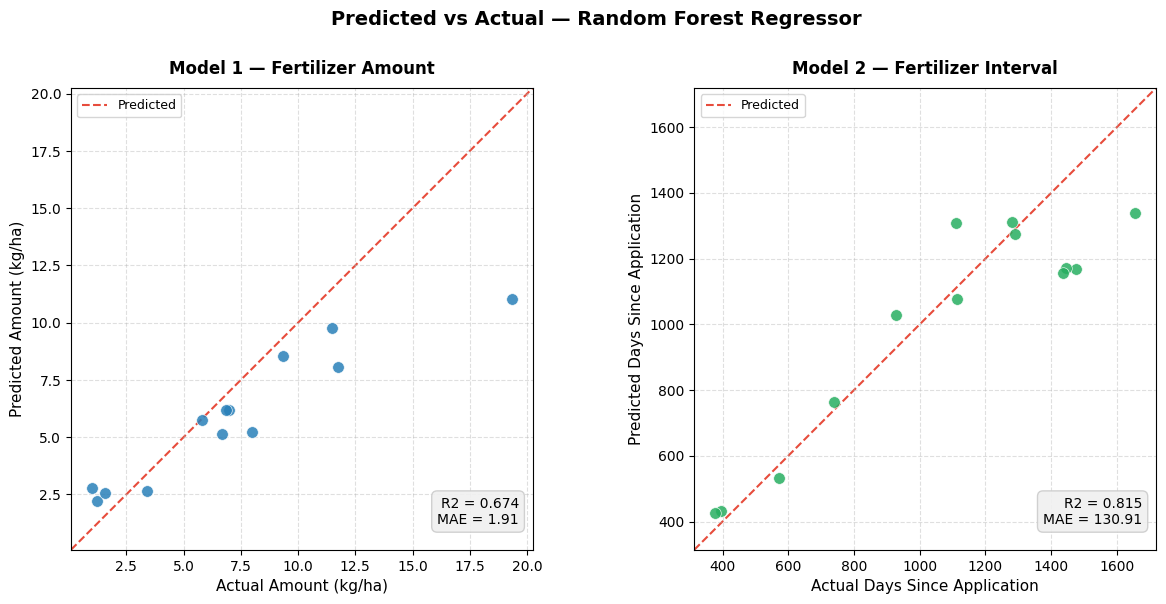

In [196]:
y_pred_amount = rf_a.predict(X_test)
y_pred_days   = rf_d.predict(X_test_d)

fig = plt.figure(figsize=(14, 6))
fig.suptitle("Predicted vs Actual — Random Forest Regressor",
             fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

def scatter_panel(ax, y_true, y_pred, title, xlabel, color):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    #prediction line
    all_vals = np.concatenate([y_true, y_pred])
    lo, hi   = all_vals.min(), all_vals.max()
    pad      = (hi - lo) * 0.05
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color='#e74c3c', linewidth=1.5, linestyle='--',
            label='Predicted', zorder=1)

    #Scatter points
    ax.scatter(y_true, y_pred, color=color, edgecolors='white',
               linewidth=0.5, s=70, alpha=0.85, zorder=2)

    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel(f"Actual {xlabel}", fontsize=11)
    ax.set_ylabel(f"Predicted {xlabel}", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=9, loc='upper left')

    #Metrics box
    textstr = f"R2 = {r2:.3f}\nMAE = {mae:.2f}"
    ax.text(0.97, 0.05, textstr, transform=ax.transAxes,
            fontsize=10, verticalalignment='bottom',
            horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f0f0', edgecolor='#cccccc', alpha=0.9))

    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_aspect('equal', adjustable='box')

#Fertilizer Amount
ax1 = fig.add_subplot(gs[0])
scatter_panel(ax1, y_test.values, y_pred_amount,
              "Model 1 — Fertilizer Amount",
              "Amount (kg/ha)", color='#2980b9')

#Days Since Application
ax2 = fig.add_subplot(gs[1])
scatter_panel(ax2, y_test_d.values, y_pred_days,
              "Model 2 — Fertilizer Interval",
              "Days Since Application", color='#27ae60')
plt.show()